# Ye & Ghassemi (2018) SW-S4 - pressure-coupling and calibration comparison

This notebook compares the SW4 hydraulic legacy double-weakening formulation, the pre-audit pressure-traction-only result when archived, the final selected corrected candidate, and the digitized Ye & Ghassemi (2018) Figure 7d curves.

Pressure-coupling convention used for the corrected deck:

- Pore pressure is applied mechanically through `OrcaCZMFluidPressureInterfaceKernel` with `pressure_traction_coefficient = -${fracture_pressure_coefficient}`. The coefficient is negative because positive pore pressure applies an opening/unloading interface traction.
- The Barton-Bandis strength-law pressure term is disabled with `bb_pore_pressure_strength_coefficient = 0.0`, avoiding a second subtraction of the same interface pressure.
- A positive BB pressure coefficient is reserved for an intentional effective-stress-only deck where pressure traction is disabled. A negative BB coefficient is not a sign fix because the C++ branch is active only for positive coefficients.

For SW4, shear traction is computed as the vector magnitude `sqrt(czm_tau_1_pp**2 + czm_tau_2_pp**2)` whenever both components are available. If only one component exists in an older CSV, the notebook reports that fallback and uses the available component magnitude.
The loader reports stale CSVs when the result file is older than its input deck; after changing the final candidate, rerun the full transient before treating the automated conclusion as validation.


In [265]:
import math
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'legend.fontsize': 8,
})

cwd = Path.cwd().resolve()
SEARCH_ROOTS = [cwd, *cwd.parents]
BASE_CANDIDATES = SEARCH_ROOTS + [
    root / 'Examples/YeGhasemmi2018/SW4_July10' for root in SEARCH_ROOTS
]

seen = set()
BASE_CANDIDATES = [path for path in BASE_CANDIDATES if not (str(path) in seen or seen.add(str(path)))]
RUN_NAME = 'SW4_68_TARGETED_RESIDUAL_SWEEPS'
BASE = next((path for path in BASE_CANDIDATES if (path / 'validation').is_dir() and (path / RUN_NAME / 'results_csv').is_dir()), None)
if BASE is None:
    searched = '\n'.join(str(path) for path in BASE_CANDIDATES)
    raise FileNotFoundError(f'Could not locate SW4_July10 with validation/ and {RUN_NAME}/results_csv. Searched:\n{searched}')
RUN_DIR = BASE / RUN_NAME
VALID = BASE / 'validation'
RESULTS = RUN_DIR / 'results_csv'

FAILURE_TIME_S = 1588.22
NEAR_FAILURE_WINDOW_S = (1500.0, 1650.0)
DEFAULT_INTENDED_END_TIME_S = 3405.0
END_TIME_TOLERANCE_S = 1.0

# Central case configuration. Archive the pre-audit CSV to the optional path below
# if the final candidate rerun will overwrite results/Ye2018_SW4_hydraulic_pressure_traction_only.csv.
cases = { 
#    'ye2018_smooth_fracture_April1_V8_DD02_cap1e6': {
#         'csv': RESULTS / 'ye2018_smooth_fracture_April1_V8_DD02_cap1e6.csv',
#         'input': BASE / 'ye2018_smooth_fracture_April1_V8_DD02_cap1e6.i',
#         'style': '-.',
#         'color': 'tab:green',
#         'kind': 'legacy',
#         'required': True,
#     },
#     'ye2018_smooth_fracture_April1_V8_DD02_cap1e6_kernels_update': {
#         'csv': RESULTS / 'ye2018_smooth_fracture_April1_V8_DD02_cap1e6_kernels_update.csv',
#         'input': BASE / 'ye2018_smooth_fracture_April1_V8_DD02_cap1e6_kernels_update.i',
#         'style': '-.',
#         'color': 'tab:blue',
#         'kind': 'legacy',
#         'required': True,
#     },
#     'ye2018_smooth_fracture_April1_V8_DD02_cap1e6_kernels_update_axial_BC': {
#         'csv': RESULTS / 'ye2018_smooth_fracture_April1_V8_DD02_cap1e6_kernels_update_axial_BC.csv',
#         'input': BASE / 'ye2018_smooth_fracture_April1_V8_DD02_cap1e6_kernels_update_axial_BC.i',
#         'style': '-.',
#         'color': 'tab:red',
#         'kind': 'legacy',
#         'required': True,
#     },


    # 'ye2018_smooth_fracture_April1_V8_DD02_cap1e6_kernels_update_new_mesh': {
    #     'csv': RESULTS / 'ye2018_smooth_fracture_April1_V8_DD02_cap1e6_kernels_update_new_mesh.csv',
    #     'input': BASE / 'ye2018_smooth_fracture_April1_V8_DD02_cap1e6_kernels_update_new_mesh.i',
    #     'style': '-.',
    #     'color': 'tab:blue',
    #     'kind': 'legacy',
    #     'required': True,
    # },
    # 'ye2018_smooth_fracture_April1_V8_DD02_cap1e6_dilation_retune': {
    #     'csv': RESULTS / 'ye2018_smooth_fracture_April1_V8_DD02_cap1e6_dilation_retune.csv',
    #     'input': BASE / 'ye2018_smooth_fracture_April1_V8_DD02_cap1e6_dilation_retune.i',
    #     'style': '-.',
    #     'color': 'tab:red',
    #     'kind': 'legacy',
    #     'required': True,
    # },
    #   '68_    
    #   '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV': {W
    #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV.csv',
    #     'input': RUN_DIR / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV.i',
    #     'style': '-.',
    #     'color': 'tab:blue',
    #     'kind': 'legacy',
    #     'required': True,
    # },
    # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel': {
    #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel.csv',
    #     'input': RUN_DIR / 'W68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel.i',
    #     'style': '-.',
    #     'color': 'tab:red',
    #     'kind': 'legacy',
    #     'required': True,
    # },
      '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV': {
        'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV.csv',
        'input': RUN_DIR / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV.i',
        'style': '-.',
        'color': 'tab:blue',
        'kind': 'legacy',
        'required': True,
    },

    '67_11_sw4_mc_dS0p15_s28_w12_m0': {
        'csv': RESULTS / '67_11_sw4_mc_dS0p15_s28_w12_m0.csv',
        'input': RUN_DIR / '67_11_sw4_mc_dS0p15_s28_w12_m0.i',
        'style': '-.',
        'color': 'tab:red',
        'kind': 'legacy',
        'required': True,
    },
    # # STAGE2 2026-08-13: kernel_SV + confining_pressure 29.4e6 -> 30.0e6 (paper's reported value).
    # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV_cp30': {
    #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV_cp30.csv',
    #     'input': RUN_DIR / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV_cp30.i',
    #     'style': '-.',
    #     'color': 'tab:green',
    #     'kind': 'legacy',
    #     'required': False,
    # },
    # # STAGE3 2026-08-13: kernel_SV_cp30 + state-dependent fault_pressure_area_coefficient
    # # (alpha = sigma_0/(sigma_0+sigma_n)), replacing the flat fault_pressure_coefficient=0.86.
    # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV_cp30_alpha': {
    #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV_cp30_alpha.csv',
    #     'input': RUN_DIR / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV_cp30_alpha.i',
    #     'style': '-.',
    #     'color': 'tab:purple',
    #     'kind': 'legacy',
    #     'required': False,
    # },

    # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV_alpha': {
    #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV_alpha.csv',
    #     'input': RUN_DIR / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV_alpha.i',
    #     'style': '-.',
    #     'color': 'tab:red',
    #     'kind': 'legacy',
    #     'required': False,
    # },

    
}
for name, cfg in cases.items():
    cfg['csv'] = Path(cfg['csv'])
    cfg['input'] = Path(cfg['input'])

print(f'Base folder: {BASE}')
for name, cfg in cases.items():
    status = 'found' if cfg['csv'].exists() else 'missing'
    print(f'{name}: {status} - {cfg["csv"].name}')

Base folder: /media/geomechanics/Data4TB/projects/orca_3.0_full/Examples/YeGhasemmi2018/SW4_July10
68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV: found - 68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV.csv
67_11_sw4_mc_dS0p15_s28_w12_m0: found - 67_11_sw4_mc_dS0p15_s28_w12_m0.csv


In [266]:
def load_digitized(name):
    path = VALID / name
    if not path.exists():
        warnings.warn(f'Missing validation file: {path}')
        return pd.DataFrame(columns=['time_s', 'value'])
    df = pd.read_csv(path, header=None, names=['time_s', 'value'])
    return df.sort_values('time_s').reset_index(drop=True)

VALIDATION_FILES = {
    'differential_stress': 'Ye2018_SW4_Differential_Stress_Vs_time.csv',
    'injection_pressure': 'Ye2018_SW4_Injection_pressure_Vs_time.csv',
    'flow_rate': 'Ye2018_SW4_flow_rate_Vs_time.csv',
    'frac_perm': 'Ye2018_SW4_frac_perm_Vs_time.csv',
    'normal_dilation': 'Ye2018_SW4_normal_dilation_Vs_time.csv',
    'normal_stress': 'Ye2018_SW4_normal_stress_Vs_time.csv',
    'shear_slip': 'Ye2018_SW4_shear_slip_Vs_time.csv',
    'shear_stress': 'Ye2018_SW4_shear_stress_Vs_time.csv',
}
validation = {key: load_digitized(filename) for key, filename in VALIDATION_FILES.items()}
missing_validation = [filename for key, filename in VALIDATION_FILES.items() if validation[key].empty]
if missing_validation:
    searched = '\n'.join(str(VALID / filename) for filename in missing_validation)
    raise FileNotFoundError(f'Missing SW4 digitized validation CSVs in {VALID}. Restore validation/ or place these files there:\n{searched}')

In [267]:
COLUMN_ALIASES = {
    'time_s': [('time', 1.0)],
    'differential_stress_mpa': [('differential_stress_mpa_pp', 1.0), ('differential_stress_pp', 1.0e-6)],
    'injection_pressure_pa': [('injection_pressure_target_pp', 1.0), ('injection_pressure_pp', 1.0)],
    'interface_pore_pressure_pa': [('fracture_pressure_mean_pp', 1.0), ('fracture_pressure_mean_target_pp', 1.0), ('injection_pressure_pp', 1.0)],
    # NOTE: flow_rate_pp is a MASS flow rate (kg/s), not volumetric (m^3/s) -- the underlying
    # Darcy/storage kernels use multiply_by_fluid_density=true. The other candidates above are
    # already volumetric mL/min and take priority; flow_rate_pp is only the last-resort fallback,
    # so its scale must first divide out fluid_density_ref (~1000 kg/m^3) before applying the
    # m^3/s -> mL/min factor of 6.0e7, i.e. 6.0e7/1000 = 6.0e4. (Previously 6.0e7, which silently
    # over-reported by ~1000x whenever this fallback path was actually taken.)
    'flow_rate_ml_min': [('flow_rate_validation_ml_min_pp', 1.0), ('flow_rate_transmissivity_target_ml_min_pp', 1.0), ('flow_rate_cubic_target_ml_min_pp', 1.0), ('flow_rate_reaction_ml_min_pp', 1.0), ('flow_rate_pp', 6.0e4)],
    'fracture_permeability_m2': [('fracture_permeability_pp', 1.0)],
    'fracture_transmissivity_m3_pa_s': [('fracture_transmissivity_pp', 1.0)],
    'hydraulic_aperture_m': [('hydraulic_aperture_pp', 1.0)],
    'bb_normal_stress_pa': [('bb_normal_stress_pp', 1.0), ('czm_sigma_n_pp', 1.0)],
    'bb_effective_normal_stress_pa': [('bb_effective_normal_stress_pp', 1.0), ('effective_normal_stress_est_pp', 1.0), ('effective_normal_stress_mpa_pp', 1.0e6)],
    'bb_limit_tau_pa': [('bb_limit_tau_pp', 1.0)],
    'shear_stress_mpa': [('shear_stress_mpa_pp', 1.0), ('shear_stress_est_pp', 1.0e-6)],
    'normal_dilation_mm': [('fracture_normal_dilation_local_mm_pp', 1.0), ('normal_dilation_validation_mm_pp', 1.0), ('czm_normal_dilation_paper_mm_pp', 1.0), ('normal_displacement_raw_mm_pp', 1.0), ('dn_lvdt_paper_mm', 1.0)],
    'shear_slip_mm': [('fracture_shear_slip_local_mm_pp', 1.0), ('shear_slip_validation_mm_pp', 1.0), ('czm_shear_slip_mm_pp', 1.0), ('shear_displacement_raw_mm_pp', 1.0), ('ds_lvdt_mm', 1.0), ('cumulative_plastic_slip_pp', 1.0e3)],
    'nonlinear_iterations': [('nl_its', 1.0), ('nonlinear_iterations', 1.0), ('nonlinear_iterations_pp', 1.0), ('num_nonlinear_iterations', 1.0)],
}

MONITORED_ALIASES = [
    'injection_pressure_pa',
    'interface_pore_pressure_pa',
    'bb_normal_stress_pa',
    'bb_effective_normal_stress_pa',
    'bb_limit_tau_pa',
    'fracture_permeability_m2',
    'fracture_transmissivity_m3_pa_s',
    'hydraulic_aperture_m',
]


def parse_end_time(input_path):
    if not input_path.exists():
        return DEFAULT_INTENDED_END_TIME_S
    text = input_path.read_text(errors='replace')
    match = re.search(r'^\s*end_time\s*=\s*([0-9.eE+-]+)\s*$', text, flags=re.MULTILINE)
    if not match:
        return DEFAULT_INTENDED_END_TIME_S
    return float(match.group(1))


def first_series(df, alias, *, case_name=None, required=False):
    for column, scale in COLUMN_ALIASES.get(alias, []):
        if column in df.columns:
            return pd.to_numeric(df[column], errors='coerce') * scale, column
    if required:
        raise KeyError(f'{case_name or "case"}: missing required column for alias {alias!r}. Tried {[c for c, _ in COLUMN_ALIASES.get(alias, [])]}')
    return None, None


def load_case(name, cfg):
    path = cfg['csv']
    if not path.exists():
        message = f'{name}: CSV not found: {path}'
        if cfg.get('required'):
            warnings.warn(message)
        else:
            print(message)
        return None

    df = pd.read_csv(path)
    if 'time' not in df.columns:
        raise KeyError(f'{name}: CSV has no time column: {path}')

    for column in df.columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')

    warnings_for_case = []
    if not df['time'].is_monotonic_increasing:
        warnings_for_case.append('time was not monotonic; sorted by time')
        df = df.sort_values('time')

    duplicate_count = int(df['time'].duplicated(keep=False).sum())
    if duplicate_count:
        warnings_for_case.append(f'dropped {duplicate_count} duplicate timestamp rows, keeping the last row for each time')
        df = df.drop_duplicates(subset='time', keep='last')

    df = df.reset_index(drop=True)
    df['accepted_dt_s'] = df['time'].diff()

    tau1 = pd.to_numeric(df['czm_tau_1_pp'], errors='coerce') if 'czm_tau_1_pp' in df.columns else None
    tau2 = pd.to_numeric(df['czm_tau_2_pp'], errors='coerce') if 'czm_tau_2_pp' in df.columns else None
    if tau1 is not None and tau2 is not None:
        df['shear_traction_magnitude_pa'] = np.sqrt(tau1**2 + tau2**2)
        shear_source = 'sqrt(czm_tau_1_pp**2 + czm_tau_2_pp**2)'
    elif tau1 is not None:
        df['shear_traction_magnitude_pa'] = tau1.abs()
        shear_source = 'abs(czm_tau_1_pp); czm_tau_2_pp missing'
        warnings_for_case.append('using one-component shear magnitude because czm_tau_2_pp is missing')
    else:
        shear_mpa, shear_column = first_series(df, 'shear_stress_mpa', case_name=name)
        if shear_mpa is not None:
            df['shear_traction_magnitude_pa'] = shear_mpa.abs() * 1.0e6
            shear_source = f'abs({shear_column}) converted from MPa'
        else:
            df['shear_traction_magnitude_pa'] = np.nan
            shear_source = 'unavailable'
            warnings_for_case.append('no shear traction columns available')

    limit_tau, limit_column = first_series(df, 'bb_limit_tau_pa', case_name=name)
    if limit_tau is not None:
        df['strength_margin_pa'] = limit_tau - df['shear_traction_magnitude_pa']
    else:
        df['strength_margin_pa'] = np.nan
        warnings_for_case.append('bb shear-strength limit unavailable; strength margin is NaN')

    intended_end_time = parse_end_time(cfg['input'])
    csv_is_stale = bool(cfg['input'].exists() and path.exists() and path.stat().st_mtime < cfg['input'].stat().st_mtime)
    if csv_is_stale:
        warnings_for_case.append('CSV is older than the input deck; rerun before treating this as final validation')

    data = {
        'name': name,
        'cfg': cfg,
        'df': df,
        'warnings': warnings_for_case,
        'intended_end_time_s': intended_end_time,
        'shear_source': shear_source,
        'csv_is_stale': csv_is_stale,
    }
    return data

loaded_cases = {}
for name, cfg in cases.items():
    data = load_case(name, cfg)
    if data is not None:
        loaded_cases[name] = data

if not loaded_cases:
    raise FileNotFoundError('No configured SW4 result CSVs were available to load.')

print(f'Loaded {len(loaded_cases)} case(s): {", ".join(loaded_cases)}')
for data in loaded_cases.values():
    for warning in data['warnings']:
        print(f'WARNING [{data["name"]}]: {warning}')
    print(f'{data["name"]}: shear source = {data["shear_source"]}')

Loaded 2 case(s): 68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV, 67_11_sw4_mc_dS0p15_s28_w12_m0
68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV: shear source = sqrt(czm_tau_1_pp**2 + czm_tau_2_pp**2)
67_11_sw4_mc_dS0p15_s28_w12_m0: shear source = sqrt(czm_tau_1_pp**2 + czm_tau_2_pp**2)


In [268]:
def min_positive(series):
    values = pd.to_numeric(series, errors='coerce')
    values = values[np.isfinite(values)]
    values = values[values > 0]
    return float(values.min()) if len(values) else np.nan


def alias_values(df, alias):
    series, column = first_series(df, alias)
    return series, column


def summarize_case(data):
    df = data['df']
    intended = data['intended_end_time_s']
    after_100 = df.loc[df['time'] > 100.0, 'accepted_dt_s']
    near = df.loc[df['time'].between(*NEAR_FAILURE_WINDOW_S), 'accepted_dt_s']

    aperture, aperture_col = alias_values(df, 'hydraulic_aperture_m')
    permeability, permeability_col = alias_values(df, 'fracture_permeability_m2')
    iterations, iterations_col = alias_values(df, 'nonlinear_iterations')

    monitored_frames = []
    monitored_columns = []
    for alias in MONITORED_ALIASES:
        series, column = alias_values(df, alias)
        if series is not None:
            monitored_frames.append(series.rename(alias))
            monitored_columns.append(column)
    monitored = pd.concat(monitored_frames, axis=1) if monitored_frames else pd.DataFrame(index=df.index)
    has_nan_inf = bool(monitored.isna().any().any() or np.isinf(monitored.to_numpy(dtype=float)).any()) if not monitored.empty else False

    return {
        'case': data['name'],
        'rows': int(len(df)),
        'accepted_timesteps': int(max(len(df) - 1, 0)),
        'final_time_s': float(df['time'].max()),
        'intended_end_time_s': float(intended),
        'passed_1588_22_s': bool(df['time'].max() > FAILURE_TIME_S),
        'reached_intended_end_time': bool(df['time'].max() >= intended - END_TIME_TOLERANCE_S),
        'min_dt_after_100_s': min_positive(after_100),
        'min_dt_1500_1650_s': min_positive(near),
        'min_strength_margin_pa': float(np.nanmin(df['strength_margin_pa'])) if 'strength_margin_pa' in df and df['strength_margin_pa'].notna().any() else np.nan,
        'min_hydraulic_aperture_m': float(np.nanmin(aperture)) if aperture is not None and aperture.notna().any() else np.nan,
        'min_fracture_permeability_m2': float(np.nanmin(permeability)) if permeability is not None and permeability.notna().any() else np.nan,
        'max_nonlinear_iterations': float(np.nanmax(iterations)) if iterations is not None and iterations.notna().any() else np.nan,
        'nonlinear_iterations_column': iterations_col or 'not available',
        'csv_is_stale': bool(data.get('csv_is_stale', False)),
        'monitored_nan_or_inf': has_nan_inf,
        'monitored_columns': ', '.join(sorted(set(monitored_columns))) if monitored_columns else 'none',
    }

summary = pd.DataFrame([summarize_case(data) for data in loaded_cases.values()])
with pd.option_context('display.max_colwidth', 120, 'display.max_columns', None):
    display(summary)

for row in summary.to_dict('records'):
    print(
        f"{row['case']}: final t={row['final_time_s']:.6g} s, "
        f"rows={row['rows']}, min dt after 100 s={row['min_dt_after_100_s']:.6g}, "
        f"min dt in 1500-1650 s={row['min_dt_1500_1650_s']:.6g}, "
        f"passed 1588.22 s={row['passed_1588_22_s']}, reached intended end={row['reached_intended_end_time']}, "
        f"max nonlinear iterations={row['max_nonlinear_iterations']} ({row['nonlinear_iterations_column']})"
    )

,case,rows,accepted_timesteps,final_time_s,intended_end_time_s,passed_1588_22_s,reached_intended_end_time,min_dt_after_100_s,min_dt_1500_1650_s,min_strength_margin_pa,min_hydraulic_aperture_m,min_fracture_permeability_m2,max_nonlinear_iterations,nonlinear_iterations_column,csv_is_stale,monitored_nan_or_inf,monitored_columns
0,68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV,2335,2334,3500.0,3405.0,True,True,0.500,1.5,-7.672192e+05,0.0,0.0,NaN,not available,False,False,"bb_effective_normal_stress_pp, bb_limit_tau_pp, czm_sigma_n_pp, fracture_permeability_pp, fracture_pressure_mean_pp,..."
1,67_11_sw4_mc_dS0p15_s28_w12_m0,2337,2336,3500.0,3405.0,True,True,0.224,1.5,-1.156593e+06,0.0,0.0,NaN,not available,False,False,"bb_effective_normal_stress_pp, bb_limit_tau_pp, czm_sigma_n_pp, fracture_permeability_pp, fracture_pressure_mean_pp,..."


68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV: final t=3500 s, rows=2335, min dt after 100 s=0.5, min dt in 1500-1650 s=1.5, passed 1588.22 s=True, reached intended end=True, max nonlinear iterations=nan (not available)
67_11_sw4_mc_dS0p15_s28_w12_m0: final t=3500 s, rows=2337, min dt after 100 s=0.224, min dt in 1500-1650 s=1.5, passed 1588.22 s=True, reached intended end=True, max nonlinear iterations=nan (not available)


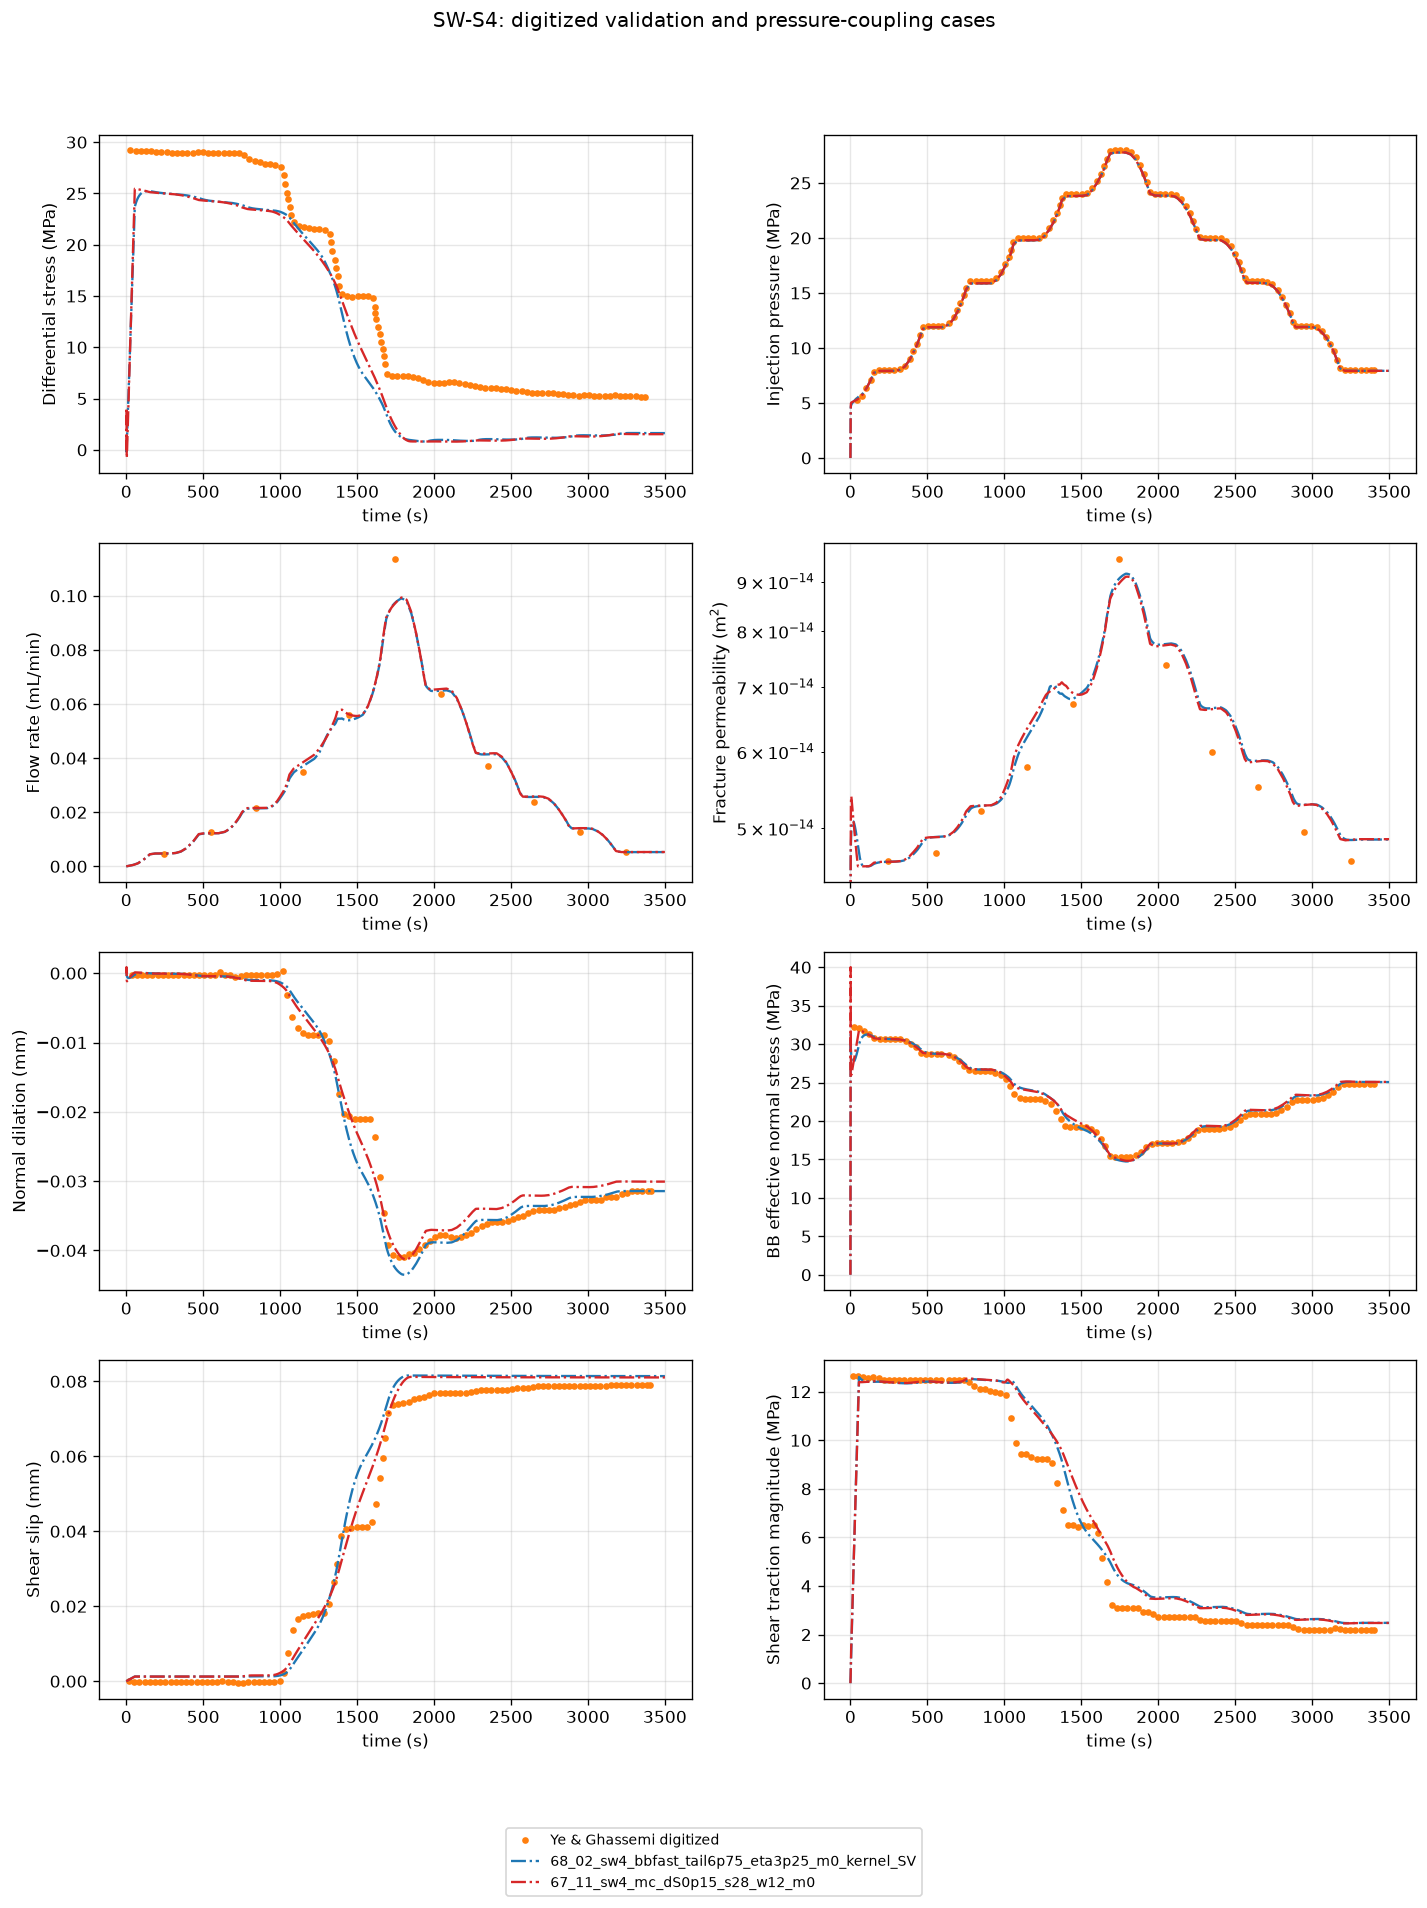

In [269]:
def get_series(data, alias, *, default=np.nan):
    series, column = first_series(data['df'], alias)
    if series is None:
        return pd.Series(default, index=data['df'].index), None
    return series, column


def plot_case_lines(ax, alias_or_column, *, scale=1.0, label_suffix='', allow_missing=True):
    plotted = False
    for name, data in loaded_cases.items():
        df = data['df']
        if alias_or_column in df.columns:
            y = pd.to_numeric(df[alias_or_column], errors='coerce') * scale
            source = alias_or_column
        else:
            y, source = first_series(df, alias_or_column)
            if y is not None:
                y = y * scale
        if y is None:
            if not allow_missing:
                print(f'{name}: missing {alias_or_column}')
            continue
        cfg = data['cfg']
        ax.plot(df['time'], y, linestyle=cfg['style'], color=cfg['color'], linewidth=1.4, label=f'{name}{label_suffix}')
        plotted = True
    return plotted


def place_bottom_legend(fig, axes=None, *, ncol=None, bottom=0.12, top=0.98):
    if axes is None:
        axes = fig.axes
    axes = np.ravel(np.atleast_1d(axes)).tolist()

    legend_items = {}
    for ax in axes:
        existing_legend = ax.get_legend()
        if existing_legend is not None:
            existing_legend.remove()
        handles, labels = ax.get_legend_handles_labels()
        for handle, label in zip(handles, labels):
            if label and not label.startswith('_') and label not in legend_items:
                legend_items[label] = handle

    if legend_items:
        if ncol is None:
            ncol = min(4, len(legend_items))
        fig.legend(
            list(legend_items.values()),
            list(legend_items.keys()),
            loc='lower center',
            bbox_to_anchor=(0.5, 0.01),
            ncol=ncol,
            fontsize='small',
            frameon=True,
        )
    fig.tight_layout(rect=(0, bottom, 1, top))


def plot_metric(ax, metric, ylabel, *, yscale=None):
    plotted = plot_case_lines(ax, metric)
    ax.set_xlabel('time (s)')
    ax.set_ylabel(ylabel)
    if yscale:
        ax.set_yscale(yscale)
    return plotted

# Paper-style validation comparison retained from the previous workflow, now for every loaded case.
panel_specs = [
    ('differential_stress', 'differential_stress_mpa', 'Differential stress (MPa)'),
    ('injection_pressure', 'injection_pressure_pa', 'Injection pressure (MPa)', 1.0e-6),
    ('flow_rate', 'flow_rate_ml_min', 'Flow rate (mL/min)'),
    ('frac_perm', 'fracture_permeability_m2', 'Fracture permeability (m$^2$)', 1.0, 'log'),
    ('normal_dilation', 'normal_dilation_mm', 'Normal dilation (mm)'),
    ('normal_stress', 'bb_effective_normal_stress_pa', 'BB effective normal stress (MPa)', 1.0e-6),
    ('shear_slip', 'shear_slip_mm', 'Shear slip (mm)'),
    ('shear_stress', 'shear_traction_magnitude_pa', 'Shear traction magnitude (MPa)', 1.0e-6),
]

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
for ax, spec in zip(axes.flat, panel_specs):
    key, alias, ylabel = spec[:3]
    scale = spec[3] if len(spec) > 3 else 1.0
    yscale = spec[4] if len(spec) > 4 else None
    v = validation.get(key)
    if v is not None and not v.empty:
        ax.plot(v['time_s'], v['value'], 'o', ms=3, color='tab:orange', label='Ye & Ghassemi digitized')
    plot_case_lines(ax, alias, scale=scale)
    ax.set_xlabel('time (s)')
    ax.set_ylabel(ylabel)
    if yscale:
        ax.set_yscale(yscale)
fig.suptitle('SW-S4: digitized validation and pressure-coupling cases', y=0.995)
place_bottom_legend(fig, axes, ncol=1, bottom=0.08, top=0.96)
fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_validation_comparison.png', bbox_inches='tight')
plt.show()

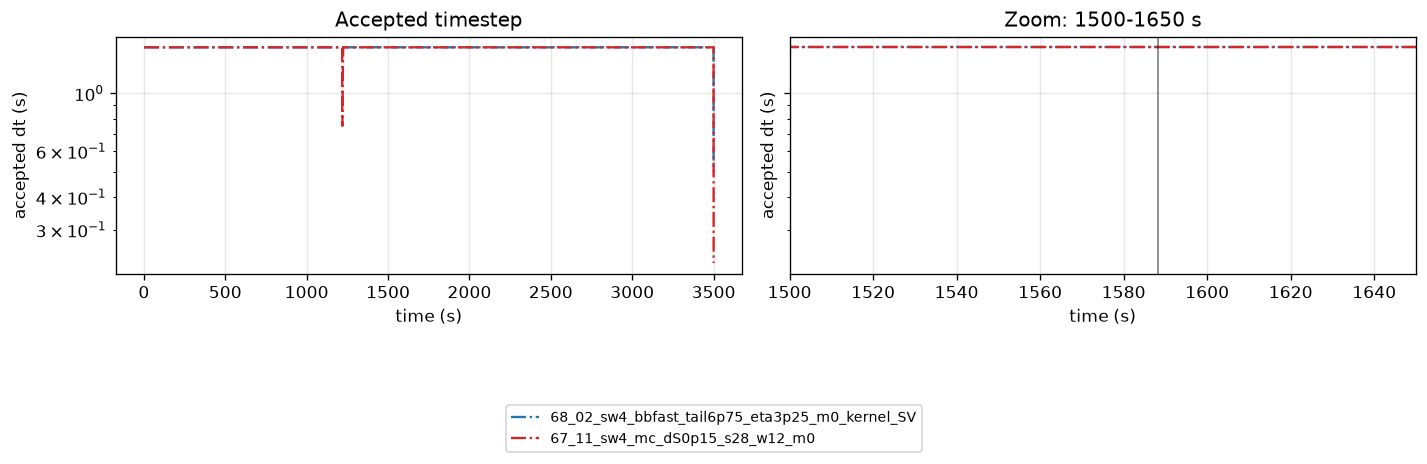

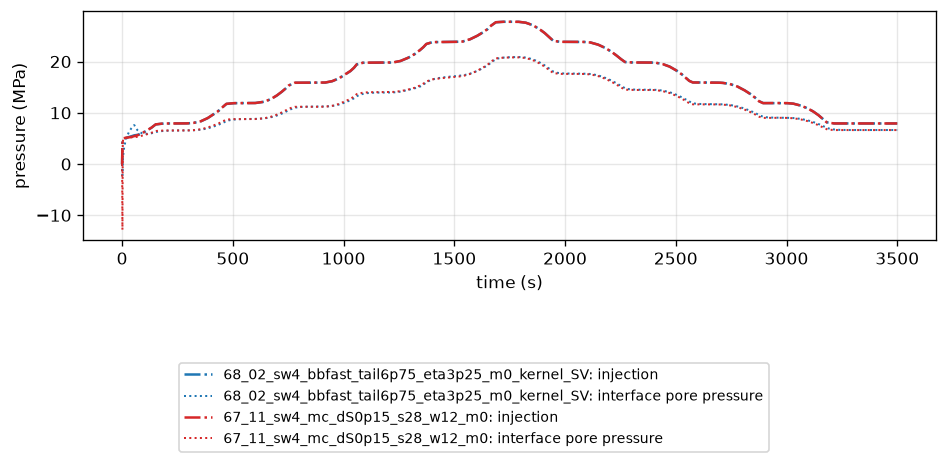

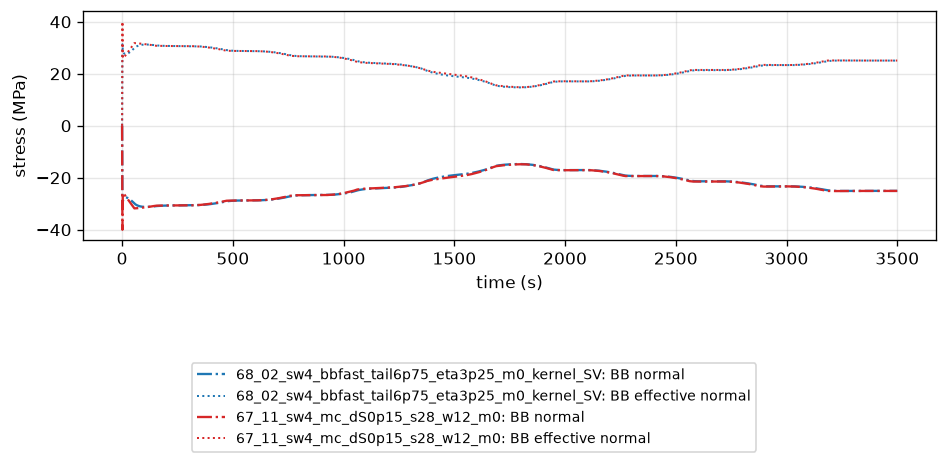

In [270]:
# 1. Accepted timestep versus time, with former-failure zoom.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_metric(axes[0], 'accepted_dt_s', 'accepted dt (s)', yscale='log')
axes[0].set_title('Accepted timestep')
plot_metric(axes[1], 'accepted_dt_s', 'accepted dt (s)', yscale='log')
axes[1].set_xlim(*NEAR_FAILURE_WINDOW_S)
axes[1].axvline(FAILURE_TIME_S, color='k', linewidth=1, alpha=0.5)
axes[1].set_title('Zoom: 1500-1650 s')
place_bottom_legend(fig, axes, ncol=1, bottom=0.25)
fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_dt.png', bbox_inches='tight')
plt.show()

# 2. Injection pressure and interface pore pressure.
fig, ax = plt.subplots(figsize=(8, 4))
for name, data in loaded_cases.items():
    df = data['df']
    cfg = data['cfg']
    inj, inj_col = first_series(df, 'injection_pressure_pa')
    pif, pif_col = first_series(df, 'interface_pore_pressure_pa')
    if inj is not None:
        ax.plot(df['time'], inj / 1.0e6, linestyle=cfg['style'], color=cfg['color'], linewidth=1.5, label=f'{name}: injection')
    if pif is not None:
        ax.plot(df['time'], pif / 1.0e6, linestyle=':', color=cfg['color'], linewidth=1.2, label=f'{name}: interface pore pressure')
ax.set_xlabel('time (s)')
ax.set_ylabel('pressure (MPa)')
place_bottom_legend(fig, ax, ncol=1, bottom=0.32)
fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_pressures.png', bbox_inches='tight')
plt.show()

# 3. Contact normal stress and BB effective normal stress.
fig, ax = plt.subplots(figsize=(8, 4))
for name, data in loaded_cases.items():
    df = data['df']
    cfg = data['cfg']
    normal, _ = first_series(df, 'bb_normal_stress_pa')
    effective, _ = first_series(df, 'bb_effective_normal_stress_pa')
    if normal is not None:
        ax.plot(df['time'], normal / 1.0e6, linestyle=cfg['style'], color=cfg['color'], linewidth=1.4, label=f'{name}: BB normal')
    if effective is not None:
        ax.plot(df['time'], effective / 1.0e6, linestyle=':', color=cfg['color'], linewidth=1.2, label=f'{name}: BB effective normal')
ax.set_xlabel('time (s)')
ax.set_ylabel('stress (MPa)')
place_bottom_legend(fig, ax, ncol=1, bottom=0.32)
fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_normal_stress.png', bbox_inches='tight')
plt.show()

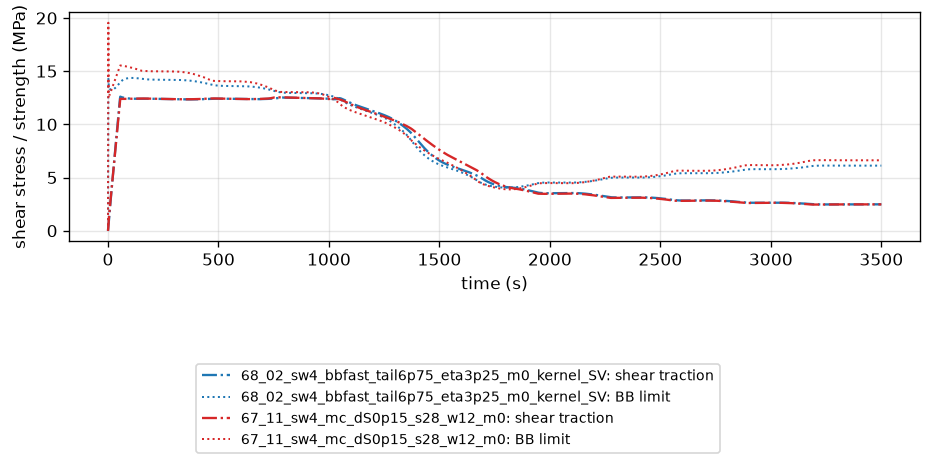

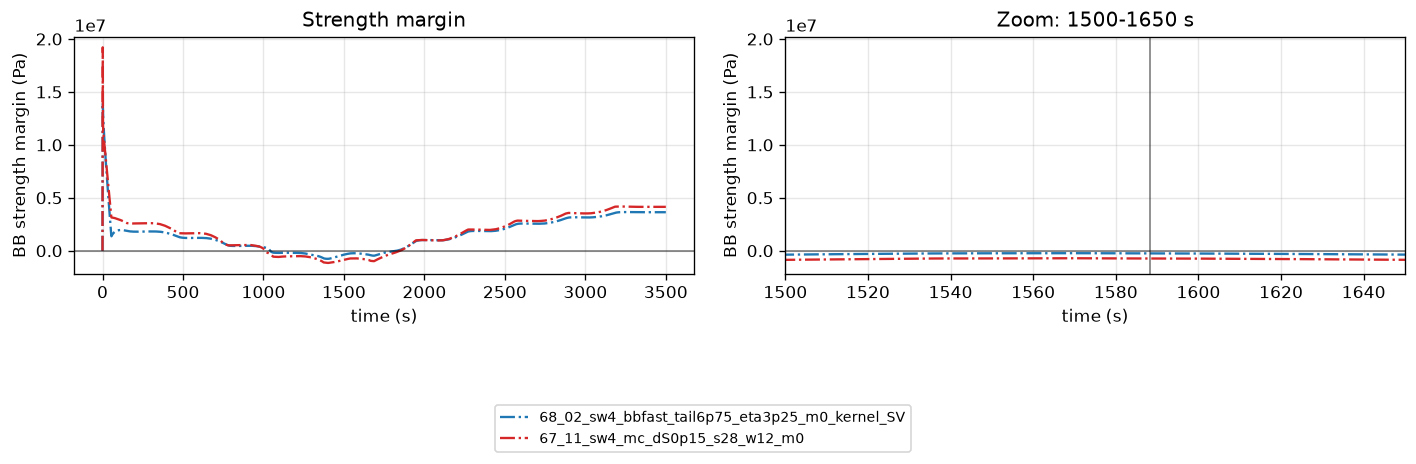

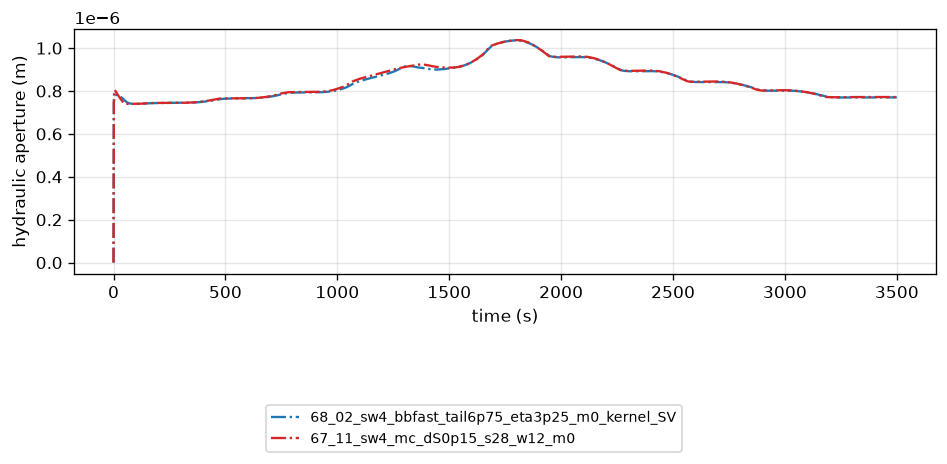

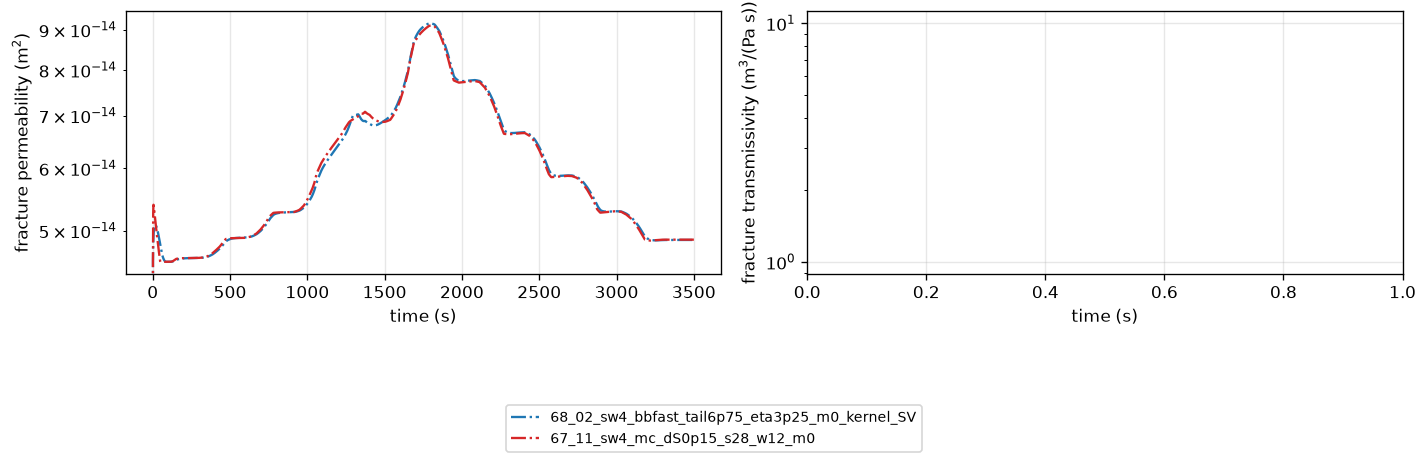

No nonlinear-iteration postprocessor column was available in the loaded CSV files.


In [271]:
# 4. Shear traction magnitude and BB shear-strength limit.
fig, ax = plt.subplots(figsize=(8, 4))
for name, data in loaded_cases.items():
    df = data['df']
    cfg = data['cfg']
    shear = df.get('shear_traction_magnitude_pa')
    limit_tau, _ = first_series(df, 'bb_limit_tau_pa')
    if shear is not None:
        ax.plot(df['time'], shear / 1.0e6, linestyle=cfg['style'], color=cfg['color'], linewidth=1.4, label=f'{name}: shear traction')
    if limit_tau is not None:
        ax.plot(df['time'], limit_tau / 1.0e6, linestyle=':', color=cfg['color'], linewidth=1.2, label=f'{name}: BB limit')
ax.set_xlabel('time (s)')
ax.set_ylabel('shear stress / strength (MPa)')
place_bottom_legend(fig, ax, ncol=1, bottom=0.32)
fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_shear_limit.png', bbox_inches='tight')
plt.show()

# 5. Shear-strength margin, with former-failure zoom.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
plot_metric(axes[0], 'strength_margin_pa', 'BB strength margin (Pa)')
axes[0].axhline(0.0, color='k', linewidth=1, alpha=0.5)
axes[0].set_title('Strength margin')
plot_metric(axes[1], 'strength_margin_pa', 'BB strength margin (Pa)')
axes[1].set_xlim(*NEAR_FAILURE_WINDOW_S)
axes[1].axhline(0.0, color='k', linewidth=1, alpha=0.5)
axes[1].axvline(FAILURE_TIME_S, color='k', linewidth=1, alpha=0.5)
axes[1].set_title('Zoom: 1500-1650 s')
place_bottom_legend(fig, axes, ncol=1, bottom=0.25)
fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_strength_margin.png', bbox_inches='tight')
plt.show()

# 6. Hydraulic aperture.
fig, ax = plt.subplots(figsize=(8, 4))
plot_metric(ax, 'hydraulic_aperture_m', 'hydraulic aperture (m)')
place_bottom_legend(fig, ax, ncol=1, bottom=0.25)
fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_aperture.png', bbox_inches='tight')
plt.show()

# 7. Fracture permeability and transmissivity.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_metric(axes[0], 'fracture_permeability_m2', 'fracture permeability (m$^2$)', yscale='log')
plot_metric(axes[1], 'fracture_transmissivity_m3_pa_s', 'fracture transmissivity (m$^3$/(Pa s))', yscale='log')
place_bottom_legend(fig, axes, ncol=1, bottom=0.25)
fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_hydraulic_properties.png', bbox_inches='tight')
plt.show()

# 8. Nonlinear iterations or solver diagnostics, if available.
fig, ax = plt.subplots(figsize=(8, 4))
plotted_iterations = plot_metric(ax, 'nonlinear_iterations', 'nonlinear iterations')
if plotted_iterations:
    place_bottom_legend(fig, ax, ncol=1, bottom=0.25)
    fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_nonlinear_iterations.png', bbox_inches='tight')
    plt.show()
else:
    plt.close(fig)
    print('No nonlinear-iteration postprocessor column was available in the loaded CSV files.')

,case,quantity,n,rmse,mae,bias
0,68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV,differential_stress,117,4.948521e+00,4.502027e+00,-4.502027e+00
1,68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV,injection_pressure,118,1.657084e-01,1.538198e-01,-1.507095e-01
2,68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV,flow_rate,11,5.182614e-03,2.694440e-03,-7.016558e-04
3,68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV,frac_perm,11,3.403780e-15,2.865736e-15,2.071586e-15
4,68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV,normal_dilation,102,2.245540e-03,1.247228e-03,-4.271279e-04
5,68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV,normal_stress,102,7.111047e-01,4.501882e-01,1.788873e-01
6,68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV,shear_slip,105,5.618254e-03,4.018929e-03,3.000773e-03
7,68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV,shear_stress,102,1.240596e+00,7.096239e-01,4.194795e-01
8,67_11_sw4_mc_dS0p15_s28_w12_m0,differential_stress,117,4.757446e+00,4.366535e+00,-4.366535e+00
9,67_11_sw4_mc_dS0p15_s28_w12_m0,injection_pressure,118,1.602543e-01,1.489427e-01,-1.489361e-01


,case,validation_slip_onset_s,model_slip_onset_s,validation_dilation_onset_s,model_dilation_onset_s,validation_stress_drop_onset_s,model_stress_drop_onset_s
0,68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV,1024.048039,1063.5,1046.203813,1060.5,1022.332388,1078.5
1,67_11_sw4_mc_dS0p15_s28_w12_m0,1024.048039,1035.0,1046.203813,1038.0,1022.332388,1050.0


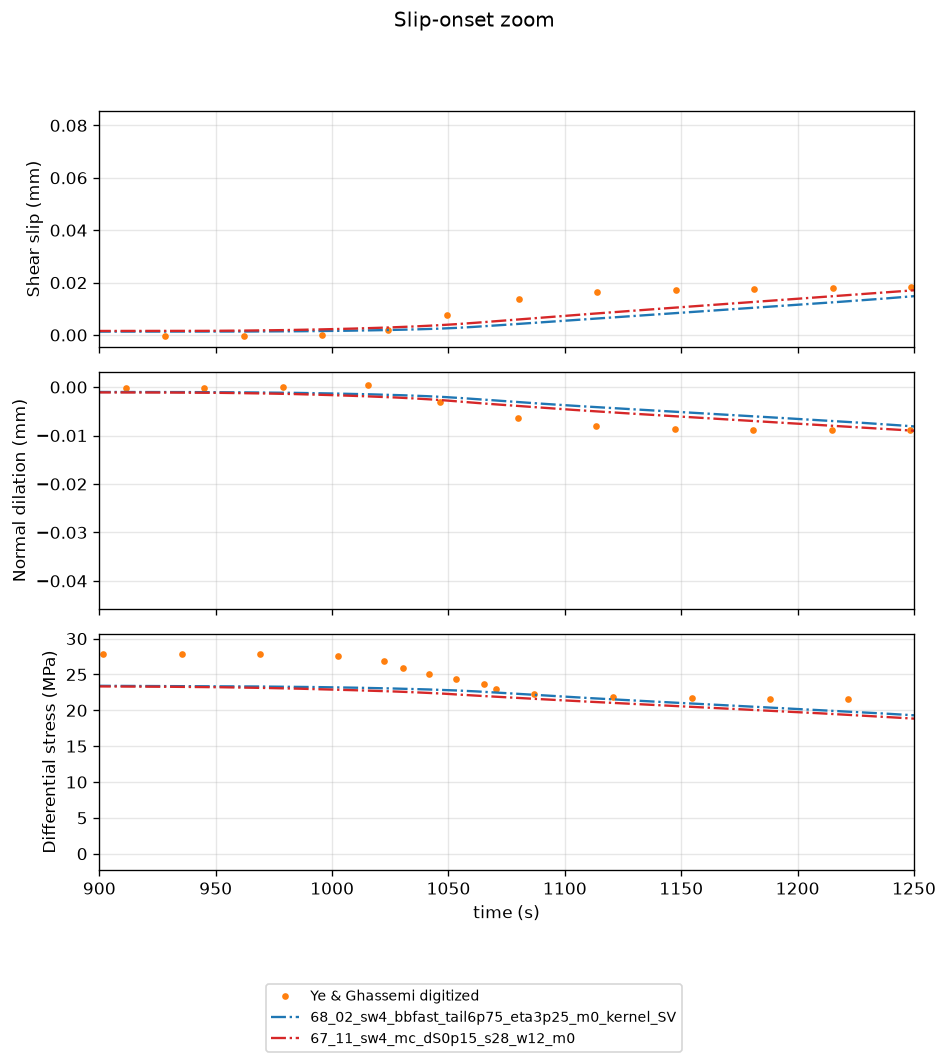

In [272]:
# Quantitative mismatch metrics and slip-onset zoom.
def interp_series(time, values, query_time):
    valid = pd.DataFrame({'time': time, 'value': values}).dropna().sort_values('time')
    if valid.empty or query_time < valid['time'].iloc[0] or query_time > valid['time'].iloc[-1]:
        return np.nan
    return float(np.interp(query_time, valid['time'], valid['value']))

metric_specs = {
    'differential_stress': ('differential_stress_mpa', 1.0),
    'injection_pressure': ('injection_pressure_pa', 1.0e-6),
    'flow_rate': ('flow_rate_ml_min', 1.0),
    'frac_perm': ('fracture_permeability_m2', 1.0),
    'normal_dilation': ('normal_dilation_mm', 1.0),
    'normal_stress': ('bb_effective_normal_stress_pa', 1.0e-6),
    'shear_slip': ('shear_slip_mm', 1.0),
    'shear_stress': ('shear_traction_magnitude_pa', 1.0e-6),
}

metric_rows = []
for case_name, data in loaded_cases.items():
    df = data['df']
    for val_key, (alias, scale) in metric_specs.items():
        vdf = validation.get(val_key)
        if vdf is None or vdf.empty:
            continue
        if alias in df.columns:
            model_values = df[alias] * scale
        else:
            series, _ = first_series(df, alias)
            if series is None:
                continue
            model_values = series * scale
        errors = []
        for t_val, y_val in zip(vdf['time_s'], vdf['value']):
            y_model = interp_series(df['time'], model_values, t_val)
            if np.isfinite(y_model):
                errors.append(y_model - y_val)
        if errors:
            errors = np.asarray(errors, dtype=float)
            metric_rows.append({
                'case': case_name,
                'quantity': val_key,
                'n': int(len(errors)),
                'rmse': float(np.sqrt(np.mean(errors**2))),
                'mae': float(np.mean(np.abs(errors))),
                'bias': float(np.mean(errors)),
            })

metrics = pd.DataFrame(metric_rows)
with pd.option_context('display.max_rows', 200, 'display.max_columns', None):
    display(metrics)

def onset_time_from_xy(time, values, *, baseline_end=900.0, threshold=0.002, direction='increase'):
    xy = pd.DataFrame({'time': time, 'value': values}).dropna().sort_values('time')
    early = xy.loc[xy['time'] <= baseline_end, 'value']
    baseline = float(early.median()) if not early.empty else float(xy['value'].iloc[0])
    for _, row in xy.loc[xy['time'] >= baseline_end].iterrows():
        delta = row['value'] - baseline
        if direction == 'increase' and delta >= threshold:
            return float(row['time'])
        if direction == 'decrease' and -delta >= threshold:
            return float(row['time'])
    return np.nan

onset_rows = []
val_slip_onset = onset_time_from_xy(validation['shear_slip']['time_s'], validation['shear_slip']['value'], threshold=0.002, direction='increase')
val_dilation_onset = onset_time_from_xy(validation['normal_dilation']['time_s'], validation['normal_dilation']['value'], threshold=0.002, direction='decrease')
val_stress_drop_onset = onset_time_from_xy(validation['differential_stress']['time_s'], validation['differential_stress']['value'], threshold=2.0, direction='decrease')
for case_name, data in loaded_cases.items():
    df = data['df']
    slip, _ = first_series(df, 'shear_slip_mm')
    dilation, _ = first_series(df, 'normal_dilation_mm')
    diff, _ = first_series(df, 'differential_stress_mpa')
    onset_rows.append({
        'case': case_name,
        'validation_slip_onset_s': val_slip_onset,
        'model_slip_onset_s': onset_time_from_xy(df['time'], slip, threshold=0.002, direction='increase') if slip is not None else np.nan,
        'validation_dilation_onset_s': val_dilation_onset,
        'model_dilation_onset_s': onset_time_from_xy(df['time'], dilation, threshold=0.002, direction='decrease') if dilation is not None else np.nan,
        'validation_stress_drop_onset_s': val_stress_drop_onset,
        'model_stress_drop_onset_s': onset_time_from_xy(df['time'], diff, threshold=2.0, direction='decrease') if diff is not None else np.nan,
    })
onsets = pd.DataFrame(onset_rows)
display(onsets)

fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
zoom = (900, 1250)
plot_items = [
    ('shear_slip', 'shear_slip_mm', 'Shear slip (mm)'),
    ('normal_dilation', 'normal_dilation_mm', 'Normal dilation (mm)'),
    ('differential_stress', 'differential_stress_mpa', 'Differential stress (MPa)'),
]
for ax, (val_key, alias, ylabel) in zip(axes, plot_items):
    vdf = validation[val_key]
    ax.plot(vdf['time_s'], vdf['value'], 'o', ms=3, color='tab:orange', label='Ye & Ghassemi digitized')
    plot_case_lines(ax, alias)
    ax.set_xlim(*zoom)
    ax.set_ylabel(ylabel)
axes[-1].set_xlabel('time (s)')
fig.suptitle('Slip-onset zoom')
place_bottom_legend(fig, axes, ncol=1, bottom=0.12, top=0.94)
fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_slip_onset_zoom.png', bbox_inches='tight')
plt.show()

In [273]:
def interp_at_time(data, column, time_s):
    df = data['df']
    if column not in df.columns or df[column].notna().sum() < 2:
        return np.nan
    valid = df[['time', column]].dropna()
    if valid.empty or time_s < valid['time'].min() or time_s > valid['time'].max():
        return np.nan
    return float(np.interp(time_s, valid['time'], valid[column]))


def select_corrected_case():
    if 'Final selected corrected candidate' in loaded_cases:
        return loaded_cases['Final selected corrected candidate'], 'final selected corrected candidate'
    for name, data in loaded_cases.items():
        if data['cfg'].get('kind', '').startswith('corrected'):
            return data, 'available corrected fallback case'
    return None, 'no corrected case available'

legacy = loaded_cases.get('Legacy double weakening')
corrected, corrected_label = select_corrected_case()

print('Automated conclusion')
print('--------------------')
if corrected is None:
    print('No corrected result CSV was loaded, so the pressure-coupling correction cannot be evaluated from results in this notebook run.')
else:
    csum = summary.loc[summary['case'] == corrected['name']].iloc[0]
    print(f'Corrected case evaluated: {corrected["name"]} ({corrected_label}).')
    print(f"Passed t = {FAILURE_TIME_S:.2f} s: {bool(csum['passed_1588_22_s'])}.")
    print(f"Reached intended end time {csum['intended_end_time_s']:.6g} s: {bool(csum['reached_intended_end_time'])} (final t = {csum['final_time_s']:.6g} s).")
    print(f"Minimum accepted dt in 1500-1650 s: {csum['min_dt_1500_1650_s']:.6g} s.")

    corr_eff = interp_at_time(corrected, 'bb_effective_normal_stress_pp', min(FAILURE_TIME_S, corrected['df']['time'].max())) / 1.0e6
    corr_margin = corrected['df'].loc[corrected['df']['time'].between(*NEAR_FAILURE_WINDOW_S), 'strength_margin_pa'].min()
    print(f'Corrected BB effective normal stress near former failure: {corr_eff:.6g} MPa.')
    print(f'Corrected minimum strength margin in 1500-1650 s: {corr_margin:.6g} Pa.')

    if legacy is not None:
        lsum = summary.loc[summary['case'] == legacy['name']].iloc[0]
        leg_eff = interp_at_time(legacy, 'bb_effective_normal_stress_pp', min(FAILURE_TIME_S, legacy['df']['time'].max())) / 1.0e6
        leg_margin = legacy['df'].loc[legacy['df']['time'].between(*NEAR_FAILURE_WINDOW_S), 'strength_margin_pa'].min()
        print(f'Legacy final time: {lsum["final_time_s"]:.6g} s; min dt in 1500-1650 s: {lsum["min_dt_1500_1650_s"]:.6g} s.')
        print(f'Legacy BB effective normal stress near former failure: {leg_eff:.6g} MPa.')
        print(f'Legacy minimum strength margin in 1500-1650 s: {leg_margin:.6g} Pa.')

    evidence_supports_removal = bool(
        csum['passed_1588_22_s']
        and not csum['monitored_nan_or_inf']
        and np.isfinite(csum['min_dt_1500_1650_s'])
        and csum['min_dt_1500_1650_s'] > 1.0e-5
    )
    if corrected.get('csv_is_stale', False):
        print('The final candidate CSV is older than the input deck; rerun the full transient before treating this as validation.')
    if corrected['name'] != 'Final selected corrected candidate':
        print('The final selected CSV was not present; this conclusion uses an existing corrected fallback result and is not final validation.')
    print(f'Data support removing duplicate pore-pressure weakening: {evidence_supports_removal}.')

Automated conclusion
--------------------
No corrected result CSV was loaded, so the pressure-coupling correction cannot be evaluated from results in this notebook run.


In [274]:
# --- Sigma3 assumption cross-check (2026-08-13 back-analysis) ---------------------------------
# differential_stress_mpa_pp (the column plotted above as "Differential stress (MPa)", and the one
# fed into the metric/onset tables) is defined in the deck as (sigma1_pp - 30e6)*1e-6: it ASSUMES
# sigma3 = 30 MPa exactly rather than measuring it (see the deck's own comment above that
# postprocessor). When the true bulk sigma3 drifts from that assumption -- e.g. under a compliant
# lateral BC as the fault opens/closes -- the naive channel silently absorbs the entire drift as
# spurious "missing" differential stress. This cross-checks q_raw against three alternatives that
# do not make the assumption: q_skeleton (uses the actually-measured domain-average sigma3),
# q_biot (Biot-corrected using measured fracture pressure), and q_reaction (load-cell-style: uses
# the top-surface reaction force and the deck's own confining_pressure parameter). The paper's own
# definition (Sec. 2.3: sigma_d = sigma1 - sigma3, sigma3 = the apparatus's SET confining pressure,
# sigma1 from the axial load cell) matches q_reaction's methodology, not a domain-averaged FEM
# stress -- so q_reaction, not q_raw, is the physically appropriate comparator to Table 2. Found
# on kernel_SV: sigma3_bulk had drifted to ~24.6 MPa (not 30), so q_raw read 1.63 MPa while
# q_reaction read 5.78 MPa against a 5.14 MPa target.

sigma3_cols = {
    'sigma3_bulk_MPa': 'sigma3_bulk_mpa_pp',
    'q_raw_assumes_sigma3=30_MPa': 'differential_stress_mpa_pp',
    'q_skeleton_bulk_MPa': 'differential_stress_skeleton_bulk_pp',
    'q_biot_corrected_MPa': 'differential_stress_biot_corrected_pp',
    'q_reaction_load_cell_style_MPa': 'differential_stress_reaction_mpa_pp',
}
q_target = float(validation['differential_stress']['value'].iloc[-1]) if not validation['differential_stress'].empty else np.nan

sigma3_check_rows = []
for case_name, data in loaded_cases.items():
    df = data['df']
    final = df.iloc[-1]
    row = {'case': case_name, 'final_time_s': float(final['time'])}
    for label, col in sigma3_cols.items():
        row[label] = float(final[col]) if col in df.columns else np.nan
    row['sigma3_drift_from_30MPa'] = row['sigma3_bulk_MPa'] - 30.0 if np.isfinite(row['sigma3_bulk_MPa']) else np.nan
    row['table2_target_MPa'] = q_target
    row['q_reaction_error_pct'] = (
        (row['q_reaction_load_cell_style_MPa'] - q_target) / q_target * 100.0
        if np.isfinite(row['q_reaction_load_cell_style_MPa']) and q_target else np.nan
    )
    row['q_raw_error_pct'] = (
        (row['q_raw_assumes_sigma3=30_MPa'] - q_target) / q_target * 100.0
        if np.isfinite(row['q_raw_assumes_sigma3=30_MPa']) and q_target else np.nan
    )
    sigma3_check_rows.append(row)

sigma3_check = pd.DataFrame(sigma3_check_rows)
print('Sigma3 assumption cross-check (final row of each case)')
with pd.option_context('display.max_columns', None, 'display.width', 160):
    display(sigma3_check)


Sigma3 assumption cross-check (final row of each case)


,case,final_time_s,sigma3_bulk_MPa,q_raw_assumes_sigma3=30_MPa,q_skeleton_bulk_MPa,q_biot_corrected_MPa,q_reaction_load_cell_style_MPa,sigma3_drift_from_30MPa,table2_target_MPa,q_reaction_error_pct,q_raw_error_pct
0,68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV,3500.0,24.554751,1.633776,7.079025,5.617380,5.778093,-5.445249,5.142899,12.350896,-68.232403
1,67_11_sw4_mc_dS0p15_s28_w12_m0,3500.0,24.545692,1.528986,6.983294,5.505872,5.675283,-5.454308,5.142899,10.351815,-70.269952


In [275]:
# --- Table-2 promotion gates (2026-08-13) -----------------------------------------------------
# From SW4_67_FINAL_FOUR/BACK_ANALYSIS_AND_FINAL_SELECTION.md gate #4: "Require final slip within
# about 0.002 mm and dilation minimum/end within about 0.003/0.002 mm before promotion." Extended
# here with shear traction and reaction-based differential stress (informational only -- no
# established gate width for these two, so they are reported but not PASS/FAIL graded; use
# q_reaction, not q_raw, per the sigma3 cross-check above).

TABLE2_TARGETS = {
    'final_shear_slip_mm': 0.0794,
    'dilation_min_mm': -0.0409,
    'dilation_end_mm': -0.0314,
    'final_shear_traction_MPa': 2.20,
    'final_differential_stress_MPa': 5.14,
}
GATE_WIDTHS = {
    'final_shear_slip_mm': 0.002,
    'dilation_min_mm': 0.003,
    'dilation_end_mm': 0.002,
}

gate_rows = []
for case_name, data in loaded_cases.items():
    df = data['df']
    slip = df['czm_shear_slip_mm_pp'] if 'czm_shear_slip_mm_pp' in df.columns else None
    dil = df['czm_normal_dilation_paper_mm_pp'] if 'czm_normal_dilation_paper_mm_pp' in df.columns else None
    tau = df['shear_traction_magnitude_pa'] if 'shear_traction_magnitude_pa' in df.columns else None
    q_reaction = df['differential_stress_reaction_mpa_pp'] if 'differential_stress_reaction_mpa_pp' in df.columns else None

    final_slip = float(slip.iloc[-1]) if slip is not None else np.nan
    dil_min = float(dil.min()) if dil is not None else np.nan
    dil_end = float(dil.iloc[-1]) if dil is not None else np.nan
    final_tau = float(tau.iloc[-1]) / 1.0e6 if tau is not None else np.nan
    final_q = float(q_reaction.iloc[-1]) if q_reaction is not None else np.nan

    row = {
        'case': case_name,
        'final_shear_slip_mm': final_slip,
        'slip_error_mm': final_slip - TABLE2_TARGETS['final_shear_slip_mm'] if np.isfinite(final_slip) else np.nan,
        'dilation_min_mm': dil_min,
        'dilation_min_error_mm': dil_min - TABLE2_TARGETS['dilation_min_mm'] if np.isfinite(dil_min) else np.nan,
        'dilation_end_mm': dil_end,
        'dilation_end_error_mm': dil_end - TABLE2_TARGETS['dilation_end_mm'] if np.isfinite(dil_end) else np.nan,
        'final_shear_traction_MPa': final_tau,
        'shear_traction_error_MPa': final_tau - TABLE2_TARGETS['final_shear_traction_MPa'] if np.isfinite(final_tau) else np.nan,
        'final_differential_stress_reaction_MPa': final_q,
        'differential_stress_error_MPa': final_q - TABLE2_TARGETS['final_differential_stress_MPa'] if np.isfinite(final_q) else np.nan,
    }
    row['slip_gate_PASS'] = bool(np.isfinite(row['slip_error_mm']) and abs(row['slip_error_mm']) <= GATE_WIDTHS['final_shear_slip_mm'])
    row['dilation_min_gate_PASS'] = bool(np.isfinite(row['dilation_min_error_mm']) and abs(row['dilation_min_error_mm']) <= GATE_WIDTHS['dilation_min_mm'])
    row['dilation_end_gate_PASS'] = bool(np.isfinite(row['dilation_end_error_mm']) and abs(row['dilation_end_error_mm']) <= GATE_WIDTHS['dilation_end_mm'])
    row['all_established_gates_PASS'] = bool(row['slip_gate_PASS'] and row['dilation_min_gate_PASS'] and row['dilation_end_gate_PASS'])
    gate_rows.append(row)

gates = pd.DataFrame(gate_rows)
print('Table-2 promotion gates (final-state comparison; note: running jobs show partial-trajectory values, not final)')
with pd.option_context('display.max_columns', None, 'display.width', 200):
    display(gates)


Table-2 promotion gates (final-state comparison; note: running jobs show partial-trajectory values, not final)


,case,final_shear_slip_mm,slip_error_mm,dilation_min_mm,dilation_min_error_mm,dilation_end_mm,dilation_end_error_mm,final_shear_traction_MPa,shear_traction_error_MPa,final_differential_stress_reaction_MPa,differential_stress_error_MPa,slip_gate_PASS,dilation_min_gate_PASS,dilation_end_gate_PASS,all_established_gates_PASS
0,68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV,0.081404,0.002004,-0.043505,-0.002605,-0.031436,-0.000036,2.482494,0.282494,5.778093,0.638093,False,True,True,False
1,67_11_sw4_mc_dS0p15_s28_w12_m0,0.081050,0.001650,-0.041345,-0.000445,-0.030066,0.001334,2.477709,0.277709,5.675283,0.535283,True,True,True,True


## Reproducibility notes

Run input validation from the repository root:

```bash
export PATH=/Users/saeedvdi/projects/miniforge/envs/moose/bin:$PATH
./orca-opt --check-input --allow-unused -i Examples/YeGhasemmi2018/SW4/Ye2018_SW4_hydraulic_pressure_traction_only.i
```

Run the full production corrected case with the original 32-rank batch settings from the SW4 directory:

```bash
sbatch Ye2018_SW4_hydraulic_pressure_traction_only.sh
```

or directly on a matching MPI environment:

```bash
cd /home/saeedvdi/links/projects/def-biaoli66/saeedvdi/projects/orca_3.0/Examples/YeGhasemmi2018/SW4
srun --mpi=pmi2 -n 32 /home/saeedvdi/links/projects/def-biaoli66/saeedvdi/projects/orca_3.0/orca-opt -i Ye2018_SW4_hydraulic_pressure_traction_only.i
```

After the CSV exists, re-execute this notebook. The automated conclusion cell will use `results/Ye2018_SW4_hydraulic_pressure_traction_only.csv` in preference to older corrected fallback CSVs.